# Linear Regression

This notebook demonstrates a standard linear regression machine learning model using
`rice_ml.Supervised_Learning.LinearRegression`, which is trained with the
`GradientDescent` helper.


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Ensure local package imports work when the notebook runs from any folder.
repo_root = Path.cwd()
while not (repo_root / "src").exists() and repo_root != repo_root.parent:
    repo_root = repo_root.parent
src_path = repo_root / "src"
if not src_path.exists():
    raise FileNotFoundError(f"Could not find src directory from {Path.cwd()}")
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from rice_ml.Supervised_Learning.linear_regression_class import LinearRegression, SingleNeuronLinearRegression
from rice_ml.processing.preprocessing import train_test_split, standardize
from rice_ml.processing.postprocessing import PostProcessor

from mlxtend.plotting import plot_decision_regions

# Set the Seaborn theme
sns.set_theme()


In [2]:
# Create a simple synthetic dataset for linear regression
rng = np.random.default_rng(42)
X = 2 * rng.random((100, 3))
true_weights = np.array([3.0, -1.5, 2.0])
y = 4 + X @ true_weights + rng.normal(scale=0.5, size=100)

print(f"Total Samples: {X.shape[0]}")
print(f"Number of Features: {X.shape[1]}")
print(f"Target Shape: {y.shape}")


Total Samples: 100
Number of Features: 3
Target Shape: (100,)


# Preprocessing

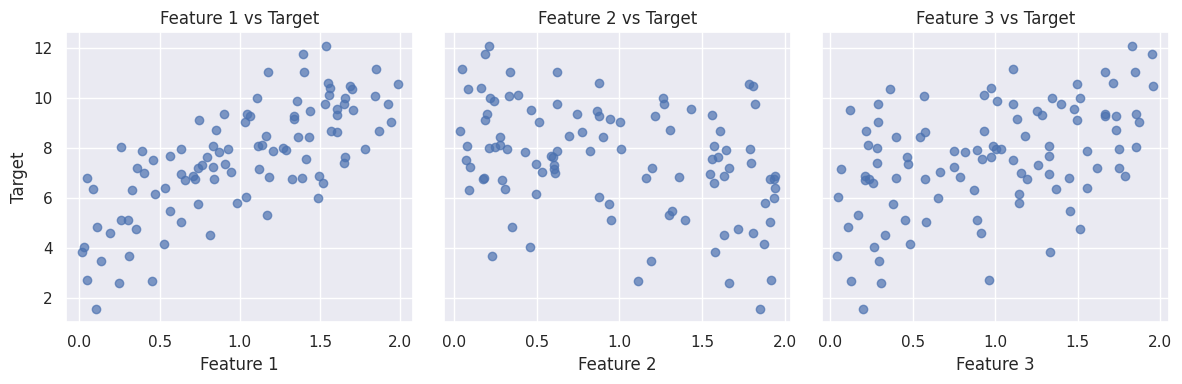

Training Set Size: 80 samples
Test Set Size: 20 samples
Training Target Size: 80 values
Standardization applied using training data only statistics.


In [3]:
# Visualize each feature against the single continuous target
fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)
for i, ax in enumerate(axes):
    ax.scatter(X[:, i], y, alpha=0.7)
    ax.set_xlabel(f"Feature {i + 1}")
    ax.set_title(f"Feature {i + 1} vs Target")
axes[0].set_ylabel("Target")
plt.tight_layout()
plt.show()

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features using standardization
X_train_scaled, X_test_scaled = standardize(X_train, X_test)

# Verification
print(f"Training Set Size: {X_train_scaled.shape[0]} samples")
print(f"Test Set Size: {X_test_scaled.shape[0]} samples")
print(f"Training Target Size: {y_train.shape[0]} values")
print("Standardization applied using training data only statistics.")


# Prediction and Evaluation

Mean Absolute Error: 0.465
Mean Squared Error: 0.309
R-squared: 0.936


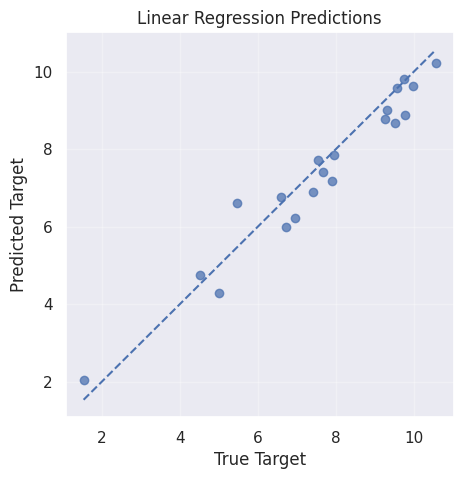

In [4]:
processor = PostProcessor()

# Instantiate and train the linear regression model
model = LinearRegression(eta=0.05, epochs=1000, random_state=7)
model.fit(X_train_scaled, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test_scaled)

# Evaluate the model using regression metrics
metrics = processor.regression_metrics(y_test, y_pred, n_features=X_train_scaled.shape[1])
print(f"Mean Absolute Error: {metrics['mae']:.3f}")
print(f"Mean Squared Error: {metrics['mse']:.3f}")
print(f"R-squared: {metrics['r2']:.3f}")

plt.figure(figsize=(5, 5))
plt.scatter(y_test, y_pred, alpha=0.75)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], linestyle="--")
plt.xlabel("True Target")
plt.ylabel("Predicted Target")
plt.title("Linear Regression Predictions")
plt.grid(True, alpha=0.3)
plt.show()
